# Spotify Dataset — Data Cleaning & Preprocessing

#### Project Proposal

## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Key variable groups
AUDIO_FEATURES = [
    'Danceability', 'Energy', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness',
    'Valence', 'Tempo', 'Duration_min'
]
TARGETS = ['Views', 'Likes', 'Comments']

print('Libraries loaded!')

Libraries loaded!


## 1. Load & Inspect Raw Data

In [2]:
df = pd.read_csv(r"D:\xwechat_files\wxid_y0440bxe6tuj12_6e1a\msg\file\2026-03\Spotify_dataset.csv")

print('Dataset Shape')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\nColumn Data Types')
print(df.dtypes)

print('\nFirst 5 Rows')
df.head()

Dataset Shape
Rows: 20,594  |  Columns: 24

Column Data Types
Artist                  str
Track                   str
Album                   str
Album_type              str
Danceability        float64
Energy              float64
Loudness            float64
Speechiness         float64
Acousticness        float64
Instrumentalness    float64
Liveness            float64
Valence             float64
Tempo               float64
Duration_min        float64
Title                   str
Channel                 str
Views                 int64
Likes                 int64
Comments              int64
Licensed               bool
official_video         bool
Stream                int64
EnergyLiveness      float64
most_playedon           str
dtype: object

First 5 Rows


,Artist,Track,Album,Album_type,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,Title,Channel,Views,Likes,Comments,Licensed,official_video,Stream,EnergyLiveness,most_playedon
0,Gorillaz,Feel Good Inc.,Demon Days,album,0.818,0.705,-6.679,0.1770,0.008360,0.002330,...,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221,6220896,169907,True,True,1040234854,1.150082,Spotify
1,Gorillaz,Rhinestone Eyes,Plastic Beach,album,0.676,0.703,-5.815,0.0302,0.086900,0.000687,...,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645,1079128,31003,True,True,310083733,15.183585,Spotify
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,0.695,0.923,-3.930,0.0522,0.042500,0.046900,...,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055,282142,7399,True,True,63063467,7.956897,Spotify
3,Gorillaz,On Melancholy Hill,Plastic Beach,album,0.689,0.739,-5.810,0.0260,0.000015,0.509000,...,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952,1788577,55229,True,True,434663559,11.546875,Spotify
4,Gorillaz,Clint Eastwood,Gorillaz,album,0.663,0.694,-8.627,0.1710,0.025300,0.000000,...,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958,6197318,155930,True,True,617259738,9.942693,Youtube


In [3]:
print('Descriptive Statistics: Audio Features')
df[AUDIO_FEATURES].describe().round(4)

Descriptive Statistics: Audio Features


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_min
count,20594.0000,20594.0000,20594.0000,20594.0000,20594.0000,20594.0000,20594.0000,20594.0000,20594.0000,20594.0000
mean,0.6201,0.6352,-7.6783,0.0967,0.2914,0.0562,0.1937,0.5301,120.5626,3.7424
std,0.1655,0.2143,4.6395,0.1122,0.2861,0.1936,0.1688,0.2455,29.5881,2.0852
min,0.0000,0.0000,-46.2510,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.5190,0.5070,-8.8680,0.0357,0.0452,0.0000,0.0941,0.3400,96.9940,2.9967
50%,0.6380,0.6660,-6.5405,0.0506,0.1930,0.0000,0.1250,0.5380,119.9590,3.5513
75%,0.7410,0.7980,-4.9350,0.1040,0.4768,0.0005,0.2370,0.7270,139.9235,4.2022
max,0.9750,1.0000,0.9200,0.9640,0.9960,1.0000,1.0000,0.9930,243.3720,77.9343


In [6]:
print('Descriptive Statistics: Engagement Variables')
desc_targets = df[TARGETS].describe()
desc_targets_formatted = desc_targets.map(lambda x: f'{x:,.0f}')

display(desc_targets_formatted)

Descriptive Statistics: Engagement Variables


,Views,Likes,Comments
count,"20,594","20,594","20,594"
mean,"92,037,404","647,990","26,847"
std,"272,602,586","1,773,648","191,175"
min,0,0,0
25%,"1,478,284","17,542",406
50%,"13,313,480","115,316","3,006"
75%,"67,396,817","500,020","13,737"
max,"8,079,649,362","50,788,652","16,083,138"


In [7]:
print('Album Type Distribution')
counts = df['Album_type'].value_counts()
pcts   = df['Album_type'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Count': counts, 'Percentage (%)': pcts.round(1)})
print(summary)

Album Type Distribution
             Count  Percentage (%)
Album_type                        
album        14834            72.0
single        4973            24.1
compilation    787             3.8


## 2. Missing Value Check

In [8]:
missing = df.isnull().sum()
print('Missing Values Per Column')
print(missing)

Missing Values Per Column
Artist              0
Track               0
Album               0
Album_type          0
Danceability        0
Energy              0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
Duration_min        0
Title               0
Channel             0
Views               0
Likes               0
Comments            0
Licensed            0
official_video      0
Stream              0
EnergyLiveness      0
most_playedon       0
dtype: int64


## 3. Duplicate Check

In [9]:
n_duplicates = df.duplicated(subset=['Artist', 'Track', 'Album']).sum()
print(f'Number of duplicate rows: {n_duplicates}')

Number of duplicate rows: 0


## 4. Outlier Review

In [10]:
print('Outlier Count per Audio Feature')
outlier_summary = []
for col in AUDIO_FEATURES:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / len(df) * 100
    outlier_summary.append({'Feature': col, 'Outliers': n_out,
                             'Percentage (%)': round(pct, 2),
                             'Lower Bound': round(lower, 4),
                             'Upper Bound': round(upper, 4)})

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))
print('\n Note: Outliers are retained — they represent genuine musical extremes')

Outlier Count per Audio Feature
         Feature  Outliers  Percentage (%)  Lower Bound  Upper Bound
    Danceability       271            1.32       0.1860       1.0740
          Energy       366            1.78       0.0705       1.2345
        Loudness      1284            6.23     -14.7675       0.9645
     Speechiness      2591           12.58      -0.0668       0.2064
    Acousticness         0            0.00      -0.6021       1.1241
Instrumentalness      4413           21.43      -0.0007       0.0012
        Liveness      1500            7.28      -0.1202       0.4513
         Valence         0            0.00      -0.2405       1.3075
           Tempo        65            0.32      32.5998     204.3178
    Duration_min       801            3.89       1.1886       6.0103

 Note: Outliers are retained — they represent genuine musical extremes


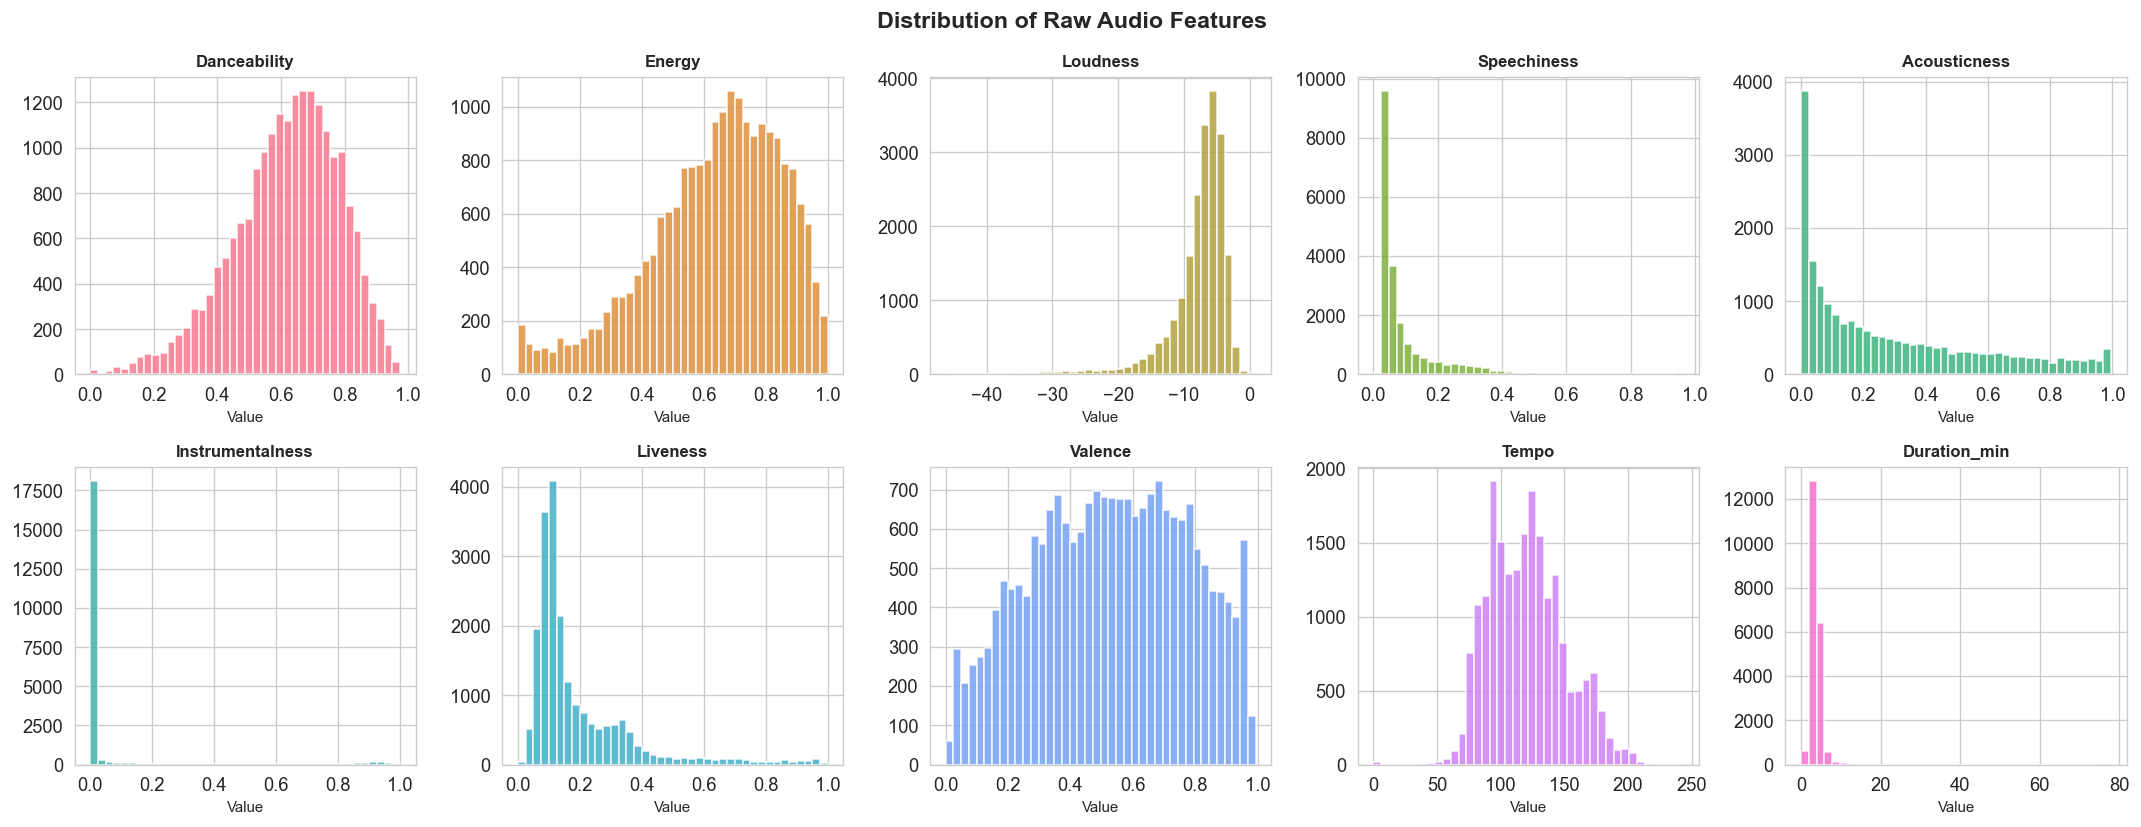

In [11]:
# Visualize distributions
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
colors = sns.color_palette('husl', 10)

for i, feat in enumerate(AUDIO_FEATURES):
    axes[i].hist(df[feat], bins=40, color=colors[i], alpha=0.8, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Value', fontsize=9)

plt.suptitle('Distribution of Raw Audio Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Log-Transform Engagement Variables

Why? Views, Likes, and Comments are severely right-skewed.  

In [12]:
df_clean = df.copy()

for col in TARGETS:
    df_clean[f'log_{col}'] = np.log1p(df_clean[col])

LOG_TARGETS = ['log_Views', 'log_Likes', 'log_Comments']

# Summary stats comparison
print('Before vs After Log Transformation')
comparison = pd.DataFrame({
    'Variable': TARGETS + LOG_TARGETS,
    'Mean':   [df_clean[c].mean() for c in TARGETS + LOG_TARGETS],
    'Std':    [df_clean[c].std()  for c in TARGETS + LOG_TARGETS],
    'Min':    [df_clean[c].min()  for c in TARGETS + LOG_TARGETS],
    'Max':    [df_clean[c].max()  for c in TARGETS + LOG_TARGETS],
    'Skewness': [df_clean[c].skew() for c in TARGETS + LOG_TARGETS]
}).round(3)
print(comparison.to_string(index=False))

Before vs After Log Transformation
    Variable         Mean          Std  Min          Max  Skewness
       Views 92037403.612 2.726026e+08  0.0 8.079649e+09     9.308
       Likes   647990.154 1.773648e+06  0.0 5.078865e+07     8.747
    Comments    26846.790 1.911751e+05  0.0 1.608314e+07    44.160
   log_Views       15.665 3.675000e+00  0.0 2.281300e+01    -1.947
   log_Likes       11.077 3.115000e+00  0.0 1.774300e+01    -1.430
log_Comments        7.491 2.977000e+00  0.0 1.659300e+01    -0.802


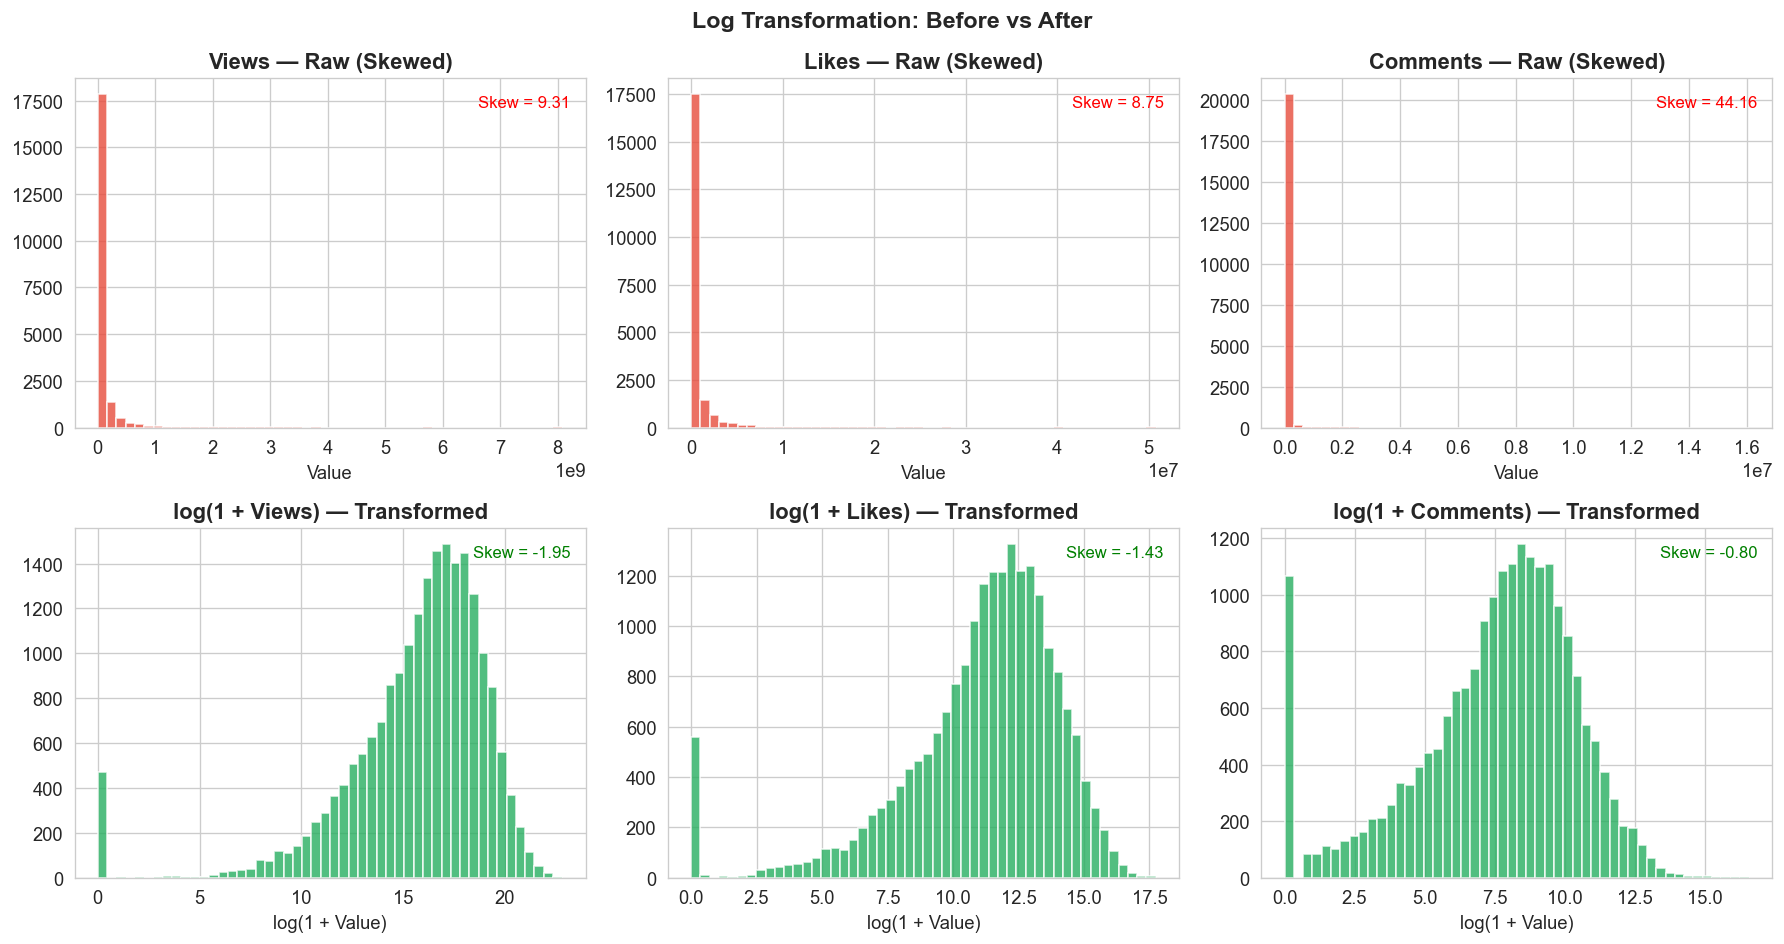

In [13]:
# Before vs after visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(TARGETS):
    axes[0, i].hist(df_clean[col], bins=50, color='#e74c3c', alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{col} — Raw (Skewed)', fontweight='bold')
    axes[0, i].set_xlabel('Value')
    skew_raw = df_clean[col].skew()
    axes[0, i].text(0.97, 0.95, f'Skew = {skew_raw:.2f}', transform=axes[0,i].transAxes,
                    ha='right', va='top', color='red', fontsize=10)

    axes[1, i].hist(df_clean[f'log_{col}'], bins=50, color='#27ae60', alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'log(1 + {col}) — Transformed', fontweight='bold')
    axes[1, i].set_xlabel('log(1 + Value)')
    skew_log = df_clean[f'log_{col}'].skew()
    axes[1, i].text(0.97, 0.95, f'Skew = {skew_log:.2f}', transform=axes[1,i].transAxes,
                    ha='right', va='top', color='green', fontsize=10)

plt.suptitle('Log Transformation: Before vs After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Check zero value counts
print("Views = 0:", (df['Views'] == 0).sum())
print("Likes = 0:", (df['Likes'] == 0).sum())
print("Comments = 0:", (df['Comments'] == 0).sum())

# Check first 10 rows of zero value count for Views
print(df[df['Views'] == 0][['Artist','Track','Album_type','Views','Likes','Comments']].head(10))

Views = 0: 470
Likes = 0: 557
Comments = 0: 1065
             Artist                Track Album_type  Views  Likes  Comments
410  Wisin & Yandel          Besos Moja2      album      0      0         0
411  Wisin & Yandel      Mayor Que Usted     single      0      0         0
412  Wisin & Yandel                Vapor      album      0      0         0
413  Wisin & Yandel          Si Te Pillo     single      0      0         0
414  Wisin & Yandel    Noche De Entierro      album      0      0         0
415  Wisin & Yandel  Algo Me Gusta De Ti      album      0      0         0
416  Wisin & Yandel        Noche De Sexo      album      0      0         0
417  Wisin & Yandel      Sexy Movimiento      album      0      0         0
418  Wisin & Yandel          Si Supieras     single      0      0         0
593     Hans Zimmer             S.T.A.Y.      album      0      0         0


In [15]:
# Remove rows where Views equals zero
df_clean = df[df['Views'] > 0].copy()

print(f"Dataset Size After Removal")
print(f"Remaining: {len(df_clean):,} rows")
print(f"Removed  : {len(df) - len(df_clean):,} rows")

# Re-apply log transformation on cleaned data
for col in ['Views', 'Likes', 'Comments']:
    df_clean[f'log_{col}'] = np.log1p(df_clean[col])

Dataset Size After Removal
Remaining: 20,124 rows
Removed  : 470 rows


## 6. Standardize Audio Features

Why？ Audio features have very different scales:  
- Loudness
- Tempo
- Danceability

In [16]:
scaler = StandardScaler()
scaled_cols = [f'{c}_scaled' for c in AUDIO_FEATURES]
df_clean[scaled_cols] = scaler.fit_transform(df_clean[AUDIO_FEATURES])

print('After StandardScaler (mean ≈ 0, std ≈ 1)')
print(df_clean[scaled_cols].describe().round(4).loc[['mean', 'std', 'min', 'max']])

After StandardScaler (mean ≈ 0, std ≈ 1)
      Danceability_scaled  Energy_scaled  Loudness_scaled  Speechiness_scaled  \
mean               0.0000        -0.0000          -0.0000             -0.0000   
std                1.0000         1.0000           1.0000              1.0000   
min               -3.7509        -2.9684          -8.3453             -0.8734   
max                2.1423         1.7067           1.8585              7.8689   

      Acousticness_scaled  Instrumentalness_scaled  Liveness_scaled  \
mean               0.0000                   0.0000          -0.0000   
std                1.0000                   1.0000           1.0000   
min               -1.0108                  -0.2904          -1.1559   
max                2.4731                   4.8753           4.8746   

      Valence_scaled  Tempo_scaled  Duration_min_scaled  
mean         -0.0000        0.0000               0.0000  
std           1.0000        1.0000               1.0000  
min          -2.1549   

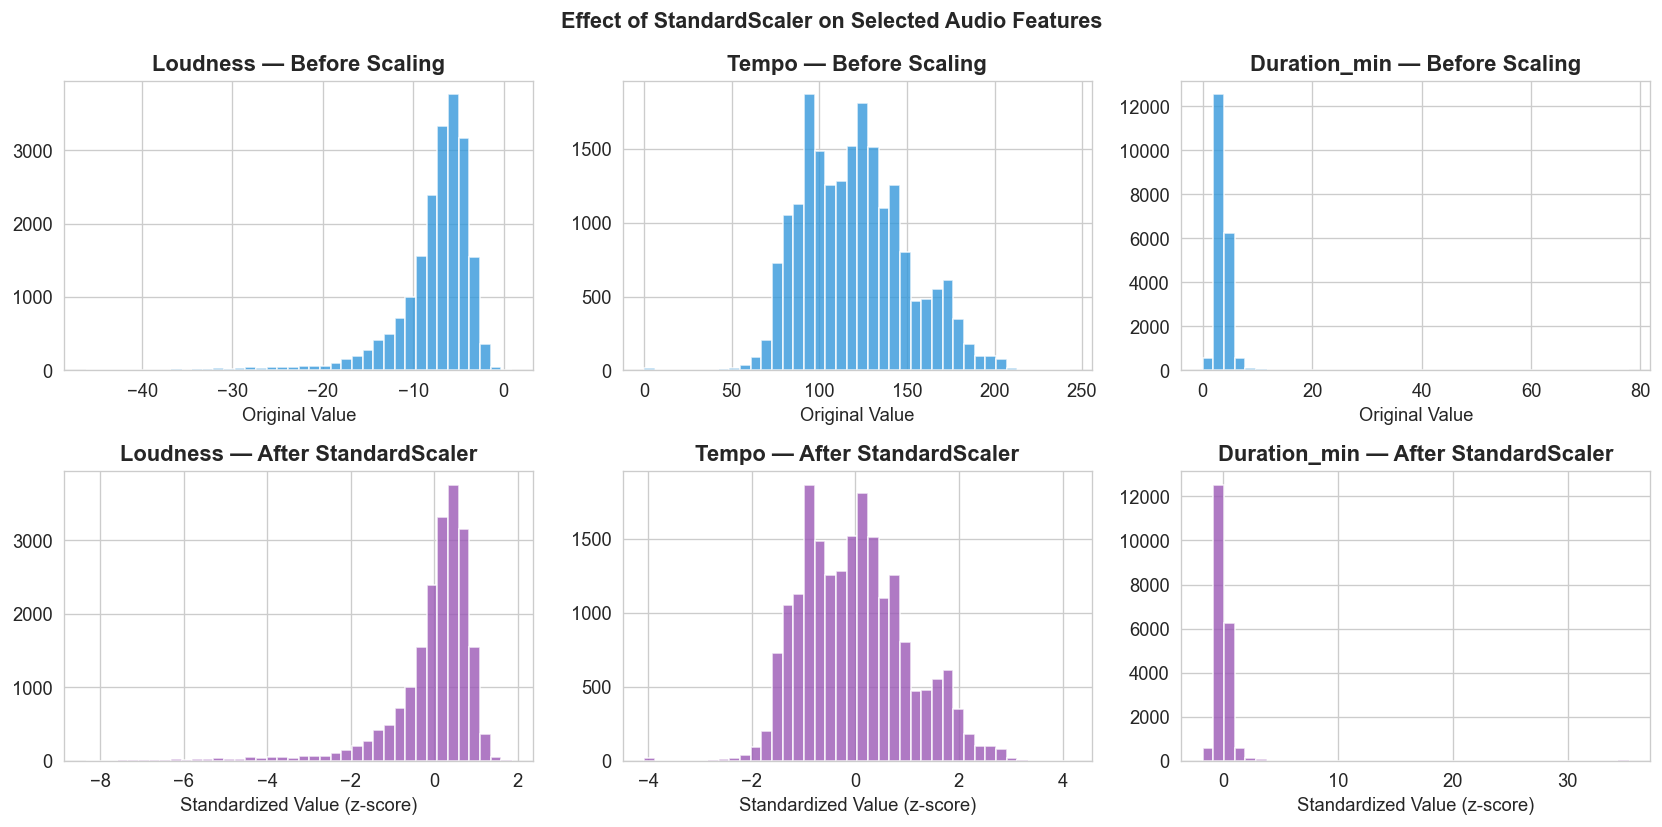

In [17]:
# Visualize scaling effect on 3 features with very different scales
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
demo_feats = ['Loudness', 'Tempo', 'Duration_min']

for i, feat in enumerate(demo_feats):
    axes[0, i].hist(df_clean[feat], bins=40, color='#3498db', alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{feat} — Before Scaling', fontweight='bold')
    axes[0, i].set_xlabel('Original Value')

    axes[1, i].hist(df_clean[f'{feat}_scaled'], bins=40, color='#9b59b6', alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'{feat} — After StandardScaler', fontweight='bold')
    axes[1, i].set_xlabel('Standardized Value (z-score)')

plt.suptitle('Effect of StandardScaler on Selected Audio Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Encode Categorical Variable: Album_type

**Why:** Linear regression requires numeric inputs. `Album_type` (album / single / compilation) must be converted.  
**Method:** One-Hot Encoding with `drop_first=True` to avoid multicollinearity (dummy variable trap).

One-Hot Encoding of Album_type
New dummy columns created:
['Album_type_compilation', 'Album_type_single']
Reference category (dropped): album


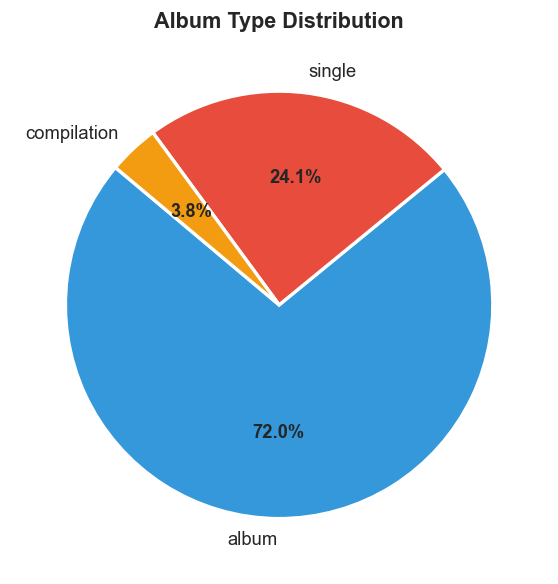

In [18]:
dummies = pd.get_dummies(df_clean['Album_type'], prefix='Album_type', drop_first=True)
df_clean = pd.concat([df_clean, dummies], axis=1)

print('One-Hot Encoding of Album_type')
print('New dummy columns created:')
print(dummies.columns.tolist())
print('Reference category (dropped): album')


# Pie chart
fig, ax = plt.subplots(figsize=(6, 5))
counts = df['Album_type'].value_counts()
wedges, texts, autotexts = ax.pie(
    counts, labels=counts.index, autopct='%1.1f%%',
    colors=['#3498db','#e74c3c','#f39c12'],
    startangle=140, wedgeprops={'edgecolor':'white','linewidth':2}
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
ax.set_title('Album Type Distribution', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Save Cleaned Dataset

In [19]:
df_clean.to_csv('Spotify_cleaned.csv', index=False)
print('Cleaned dataset saved as: Spotify_cleaned.csv')
print(f'Final shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

Cleaned dataset saved as: Spotify_cleaned.csv
Final shape: 20,124 rows × 39 columns


## Q1.  latent musical style dimensions

In [21]:
# ============================================================
# Q1. Latent Musical Style Dimensions
# PCA + Factor Analysis on 9 Spotify Audio Features
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)


# ============================================================
# 0. Basic Settings
# ============================================================

DATA_PATH = "Spotify_cleaned.csv"
OUTPUT_DIR = "q1_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

audio_features = [
    "Danceability",
    "Energy",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Instrumentalness",
    "Liveness",
    "Valence",
    "Tempo"
]

scaled_features = [col + "_scaled" for col in audio_features]

# For this project, we retain 3 dimensions because:
# 1. PCA eigenvalues / scree plot usually support a small number of dimensions
# 2. 3 factors are easier to interpret musically
# 3. Q2 can use these 3 factor scores for clustering
CHOSEN_N_FACTORS = 3



In [22]:
# 1. Load Cleaned Dataset
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

# Check whether all required raw audio feature columns exist
missing_audio_cols = [col for col in audio_features if col not in df.columns]

if missing_audio_cols:
    raise ValueError(f"Missing required audio feature columns: {missing_audio_cols}")

# Decide whether to use already scaled columns or scale raw columns here
if all(col in df.columns for col in scaled_features):
    feature_cols_to_use = scaled_features
    print("Using existing standardized audio feature columns.")
else:
    feature_cols_to_use = audio_features
    print("Scaled columns not found. Standardizing raw audio features now.")

# Check missing values before modeling
print("\nMissing values in selected feature columns:")
display(df[feature_cols_to_use].isna().sum())

# Drop rows with missing values in selected features
valid_idx = df[feature_cols_to_use].dropna().index
df_model = df.loc[valid_idx].copy()

print("\nRows used for Q1 modeling:", df_model.shape[0])
print("Rows removed due to missing audio features:", df.shape[0] - df_model.shape[0])

# Build X matrix
if feature_cols_to_use == scaled_features:
    X = df_model[scaled_features].copy()
    X.columns = audio_features
else:
    scaler = StandardScaler()
    X = pd.DataFrame(
        scaler.fit_transform(df_model[audio_features]),
        columns=audio_features,
        index=df_model.index
    )

print("\nMean after standardization:")
display(X.mean().round(3))

print("\nStandard deviation after standardization:")
display(X.std(ddof=0).round(3))

Dataset shape: (20124, 39)


,Artist,Track,Album,Album_type,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,Loudness_scaled,Speechiness_scaled,Acousticness_scaled,Instrumentalness_scaled,Liveness_scaled,Valence_scaled,Tempo_scaled,Duration_min_scaled,Album_type_compilation,Album_type_single
0,Gorillaz,Feel Good Inc.,Demon Days,album,0.818,0.705,-6.679,0.1770,0.008360,0.002330,...,0.214717,0.731762,-0.981589,-0.278330,2.540829,0.986665,0.609410,-0.016433,False,False
1,Gorillaz,Rhinestone Eyes,Plastic Beach,album,0.676,0.703,-5.815,0.0302,0.086900,0.000687,...,0.401614,-0.599532,-0.706863,-0.286817,-0.876659,1.312211,-0.938953,-0.194845,False,False
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,0.695,0.923,-3.930,0.0522,0.042500,0.046900,...,0.809369,-0.400019,-0.862170,-0.048097,-0.456333,0.087345,-0.423272,-0.075911,False,True
3,Gorillaz,On Melancholy Hill,Plastic Beach,album,0.689,0.739,-5.810,0.0260,0.000015,0.509000,...,0.402695,-0.637621,-1.010779,2.338954,-0.769919,0.197216,-0.003742,0.072722,False,False
4,Gorillaz,Clint Eastwood,Gorillaz,album,0.663,0.694,-8.627,0.1710,0.025300,0.000000,...,-0.206666,0.677350,-0.922334,-0.290366,-0.734942,-0.018458,1.603178,0.922841,False,False


Using existing standardized audio feature columns.

Missing values in selected feature columns:


Danceability_scaled        0
Energy_scaled              0
Loudness_scaled            0
Speechiness_scaled         0
Acousticness_scaled        0
Instrumentalness_scaled    0
Liveness_scaled            0
Valence_scaled             0
Tempo_scaled               0
dtype: int64


Rows used for Q1 modeling: 20124
Rows removed due to missing audio features: 0

Mean after standardization:


Danceability        0.0
Energy             -0.0
Loudness           -0.0
Speechiness        -0.0
Acousticness        0.0
Instrumentalness    0.0
Liveness           -0.0
Valence            -0.0
Tempo               0.0
dtype: float64


Standard deviation after standardization:


Danceability        1.0
Energy              1.0
Loudness            1.0
Speechiness         1.0
Acousticness        1.0
Instrumentalness    1.0
Liveness            1.0
Valence             1.0
Tempo               1.0
dtype: float64


Correlation Matrix:


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
Danceability,1.000,0.236,0.355,0.215,-0.277,-0.319,-0.084,0.464,-0.062
Energy,0.236,1.000,0.745,0.074,-0.660,-0.312,0.172,0.389,0.157
Loudness,0.355,0.745,1.000,0.048,-0.551,-0.547,0.084,0.312,0.141
Speechiness,0.215,0.074,0.048,1.000,-0.085,-0.112,0.080,0.059,0.043
Acousticness,-0.277,-0.660,-0.551,-0.085,1.000,0.276,-0.049,-0.199,-0.132
Instrumentalness,-0.319,-0.312,-0.547,-0.112,0.276,1.000,-0.058,-0.269,-0.078
Liveness,-0.084,0.172,0.084,0.080,-0.049,-0.058,1.000,0.030,0.006
Valence,0.464,0.389,0.312,0.059,-0.199,-0.269,0.030,1.000,0.093
Tempo,-0.062,0.157,0.141,0.043,-0.132,-0.078,0.006,0.093,1.000


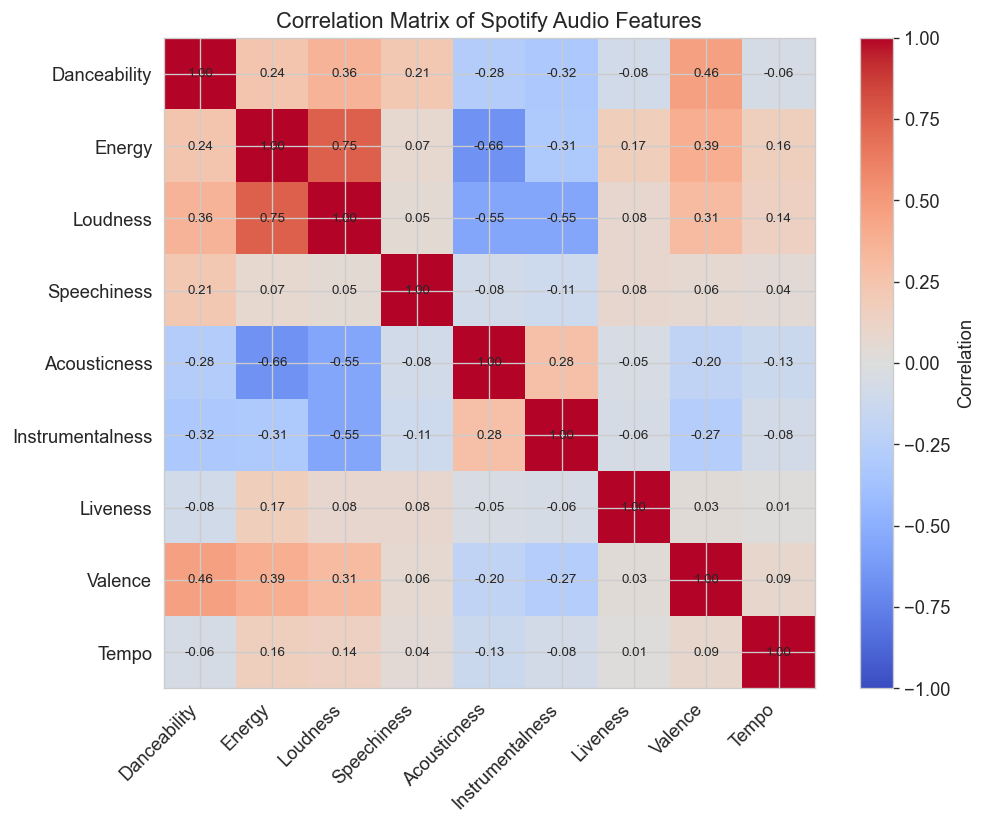

In [23]:
# ============================================================
# 2. Correlation Matrix
# Purpose:
# Check whether the 9 audio features are correlated enough
# to justify dimension reduction.
# ============================================================

corr_matrix = X.corr()

print("\nCorrelation Matrix:")
display(corr_matrix.round(3))

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(audio_features)),
    audio_features,
    rotation=45,
    ha="right"
)
plt.yticks(range(len(audio_features)), audio_features)

for i in range(len(audio_features)):
    for j in range(len(audio_features)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix of Spotify Audio Features")
plt.tight_layout()

corr_path = os.path.join(OUTPUT_DIR, "Q1_correlation_heatmap.png")
plt.savefig(corr_path, dpi=300)
plt.show()

In [24]:
# ============================================================
# 3. PCA: Determine Number of Latent Dimensions
# Purpose:
# PCA is used here to inspect eigenvalues and explained variance.
# It helps justify how many latent dimensions to retain.
# ============================================================

pca_full = PCA()
pca_full.fit(X)

eigenvalues = pca_full.explained_variance_
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

pca_summary = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(audio_features))],
    "Eigenvalue": eigenvalues,
    "Explained Variance Ratio": explained_variance_ratio,
    "Cumulative Variance": cumulative_variance
})

print("\nPCA Summary:")
display(pca_summary.round(3))

kaiser_n = int(np.sum(eigenvalues > 1))

print(f"\nNumber of components suggested by Kaiser criterion eigenvalue > 1: {kaiser_n}")
print(f"Number of factors retained for this project: {CHOSEN_N_FACTORS}")

if kaiser_n != CHOSEN_N_FACTORS:
    print(
        "\nNote: The chosen number of factors is not exactly the same as the Kaiser result. "
        "This is acceptable if supported by scree plot, cumulative variance, and interpretability."
    )



PCA Summary:


,Component,Eigenvalue,Explained Variance Ratio,Cumulative Variance
0,PC1,3.090,0.343,0.343
1,PC2,1.217,0.135,0.479
2,PC3,1.050,0.117,0.595
3,PC4,0.977,0.109,0.704
4,PC5,0.858,0.095,0.799
5,PC6,0.778,0.086,0.886
6,PC7,0.491,0.055,0.940
7,PC8,0.377,0.042,0.982
8,PC9,0.163,0.018,1.000



Number of components suggested by Kaiser criterion eigenvalue > 1: 3
Number of factors retained for this project: 3


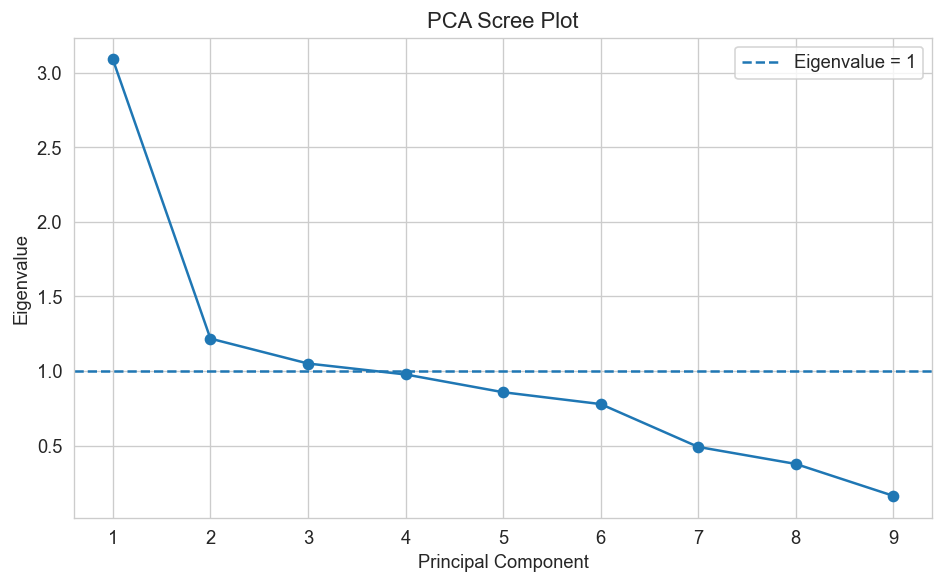

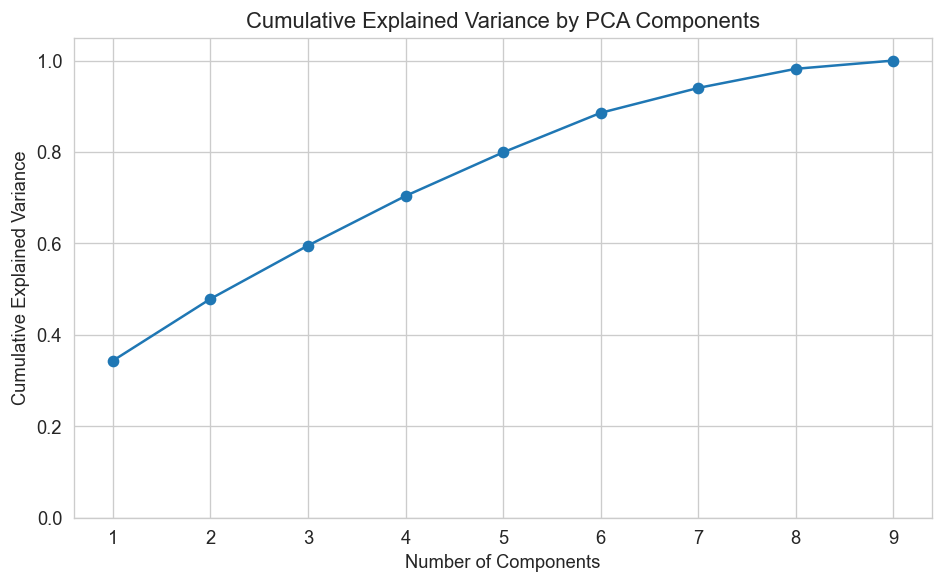

In [25]:
# 4. PCA Scree Plot and Cumulative Explained Variance Plot
# Purpose:
# These plots are useful for PPT explanation.
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(eigenvalues) + 1),
    eigenvalues,
    marker="o"
)

plt.axhline(y=1, linestyle="--", label="Eigenvalue = 1")

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("PCA Scree Plot")
plt.xticks(range(1, len(eigenvalues) + 1))
plt.legend()
plt.tight_layout()

scree_path = os.path.join(OUTPUT_DIR, "Q1_pca_scree_plot.png")
plt.savefig(scree_path, dpi=300)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA Components")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.ylim(0, 1.05)
plt.tight_layout()

cumvar_path = os.path.join(OUTPUT_DIR, "Q1_pca_cumulative_variance.png")
plt.savefig(cumvar_path, dpi=300)
plt.show()


In [26]:
# 5. Factor Analysis with Varimax Rotation
# Purpose:
# This is the true Factor Analysis step.
# PCA above helps decide how many dimensions to keep.
# Factor Analysis extracts latent factors and Varimax rotation
# improves interpretability.
# ============================================================

fa = FactorAnalysis(
    n_components=CHOSEN_N_FACTORS,
    rotation="varimax",
    random_state=42
)

fa_scores = fa.fit_transform(X)

raw_factor_names = [f"Factor{i+1}" for i in range(CHOSEN_N_FACTORS)]

fa_loadings_df = pd.DataFrame(
    fa.components_.T,
    index=audio_features,
    columns=raw_factor_names
)

fa_scores_df = pd.DataFrame(
    fa_scores,
    index=df_model.index,
    columns=raw_factor_names
)

print("\nRaw Factor Analysis Loadings with Varimax Rotation:")
display(fa_loadings_df.round(3))

print("\nRaw Factor Scores Preview:")
display(fa_scores_df.head())




Raw Factor Analysis Loadings with Varimax Rotation:


,Factor1,Factor2,Factor3
Danceability,-0.114,-0.973,-0.142
Energy,-0.961,-0.094,-0.249
Loudness,-0.549,-0.184,-0.804
Speechiness,-0.064,-0.217,0.031
Acousticness,0.610,0.179,0.229
Instrumentalness,0.169,0.235,0.511
Liveness,-0.188,0.108,-0.001
Valence,-0.348,-0.428,-0.054
Tempo,-0.147,0.093,-0.097



Raw Factor Scores Preview:


,Factor1,Factor2,Factor3
0,-0.276923,-1.194731,0.181859
1,-0.237323,-0.291041,-0.263377
2,-1.355025,-0.288216,-0.024553
3,-0.461421,-0.345070,-0.055522
4,-0.399891,-0.291485,0.553962


In [36]:
# 6. Automatically Match Factors to Interpretable Music Dimensions
# Purpose:
# Factor order is not guaranteed. This section matches each raw
# factor to a music interpretation based on which features load
# strongly on it.
#
# Important:
# After running the code, you should still inspect the loading table.
# If the actual loadings differ from the labels, rename factors manually.
# ============================================================

expected_dimensions = [
    {
        "final_name": "Factor1_Intensity_Electronic",
        "anchor": "Energy",
        "related_features": ["Energy", "Loudness", "Acousticness", "Instrumentalness"]
    },
    {
        "final_name": "Factor2_Danceability_Positive",
        "anchor": "Danceability",
        "related_features": ["Danceability", "Valence", "Tempo"]
    },
    {
        "final_name": "Factor3_Loudness / Instrumental Contrast",
        "anchor": "Liveness",
        "related_features": ["Liveness", "Speechiness"]
    }
]

available_raw_factors = set(raw_factor_names)

interpreted_loadings = pd.DataFrame(index=audio_features)
interpreted_scores = pd.DataFrame(index=df_model.index)

factor_mapping_records = []

for dim in expected_dimensions:
    final_name = dim["final_name"]
    anchor = dim["anchor"]
    related_features = dim["related_features"]

    # Score each available raw factor by how strongly it is associated
    # with the expected related features.
    matching_scores = {}

    for raw_factor in available_raw_factors:
        score = 0

        for feature in related_features:
            if feature in fa_loadings_df.index:
                score += abs(fa_loadings_df.loc[feature, raw_factor])

        matching_scores[raw_factor] = score

    best_raw_factor = max(matching_scores, key=matching_scores.get)

    # Copy loadings and scores
    interpreted_loadings[final_name] = fa_loadings_df[best_raw_factor].copy()
    interpreted_scores[final_name] = fa_scores_df[best_raw_factor].copy()

    # Flip signs so the anchor feature has a positive loading
    # This makes interpretation easier.
    if interpreted_loadings.loc[anchor, final_name] < 0:
        interpreted_loadings[final_name] *= -1
        interpreted_scores[final_name] *= -1

    factor_mapping_records.append({
        "Interpreted Factor": final_name,
        "Original Raw Factor": best_raw_factor,
        "Anchor Feature": anchor,
        "Matching Score": matching_scores[best_raw_factor]
    })

    available_raw_factors.remove(best_raw_factor)

factor_mapping_df = pd.DataFrame(factor_mapping_records)

print("\nFactor Mapping:")
display(factor_mapping_df.round(3))

print("\nFinal Interpreted Factor Loadings:")
display(interpreted_loadings.round(3))

print("\nFinal Interpreted Factor Scores Preview:")
display(interpreted_scores.head())



Factor Mapping:


,Interpreted Factor,Original Raw Factor,Anchor Feature,Matching Score
0,Factor1_Intensity_Electronic,Factor1,Energy,2.289
1,Factor2_Danceability_Positive,Factor2,Danceability,1.494
2,Factor3_Loudness / Instrumental Contrast,Factor3,Liveness,0.032



Final Interpreted Factor Loadings:


,Factor1_Intensity_Electronic,Factor2_Danceability_Positive,Factor3_Loudness / Instrumental Contrast
Danceability,0.114,0.973,0.142
Energy,0.961,0.094,0.249
Loudness,0.549,0.184,0.804
Speechiness,0.064,0.217,-0.031
Acousticness,-0.610,-0.179,-0.229
Instrumentalness,-0.169,-0.235,-0.511
Liveness,0.188,-0.108,0.001
Valence,0.348,0.428,0.054
Tempo,0.147,-0.093,0.097



Final Interpreted Factor Scores Preview:


,Factor1_Intensity_Electronic,Factor2_Danceability_Positive,Factor3_Loudness / Instrumental Contrast
0,0.276923,1.194731,-0.181859
1,0.237323,0.291041,0.263377
2,1.355025,0.288216,0.024553
3,0.461421,0.345070,0.055522
4,0.399891,0.291485,-0.553962


In [28]:
# ============================================================
# 7. Communalities and Uniqueness
# Purpose:
# Communality shows how much of each feature's variance is captured
# by the retained latent factors.
# ============================================================

communalities = (interpreted_loadings ** 2).sum(axis=1)

# In sklearn FactorAnalysis, noise_variance_ represents uniqueness-like residual variance.
# Because factors may be reordered above, noise variance is still feature-level and unaffected.
uniqueness = pd.Series(
    fa.noise_variance_,
    index=audio_features,
    name="Uniqueness"
)

communality_table = pd.DataFrame({
    "Communality": communalities,
    "Uniqueness": uniqueness
})

print("\nCommunality and Uniqueness Table:")
display(communality_table.round(3))


# ============================================================
# 8. Variance Explained by Rotated Factors
# Purpose:
# This table helps summarize how much variance each interpreted
# factor accounts for after rotation.
# ============================================================

ss_loadings = (interpreted_loadings ** 2).sum(axis=0)
proportion_variance = ss_loadings / len(audio_features)
cumulative_proportion = proportion_variance.cumsum()

factor_variance_table = pd.DataFrame({
    "SS Loadings": ss_loadings,
    "Proportion Variance": proportion_variance,
    "Cumulative Proportion": cumulative_proportion
})

print("\nFactor Variance Table:")
display(factor_variance_table.round(3))


Communality and Uniqueness Table:


,Communality,Uniqueness
Danceability,0.980,0.020
Energy,0.995,0.005
Loudness,0.981,0.019
Speechiness,0.052,0.948
Acousticness,0.456,0.544
Instrumentalness,0.345,0.655
Liveness,0.047,0.953
Valence,0.307,0.693
Tempo,0.040,0.960



Factor Variance Table:


,SS Loadings,Proportion Variance,Cumulative Proportion
Factor1_Intensity_Electronic,1.821,0.202,0.202
Factor2_Danceability_Positive,1.327,0.147,0.350
Factor3_Live_Speech_Presence,1.055,0.117,0.467


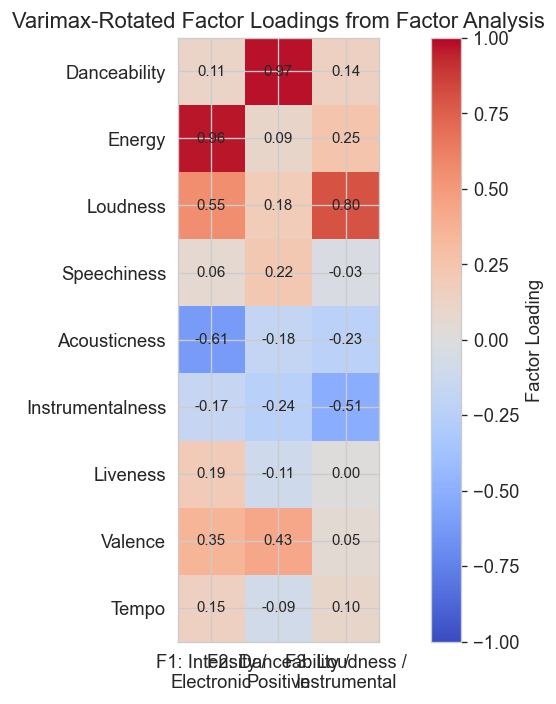

In [37]:
# 9. Factor Loading Heatmap
# Purpose:
# This is the best Q1 plot for PPT.
# It shows which audio features define each latent dimension.
# ============================================================

plt.figure(figsize=(9, 6))

plt.imshow(interpreted_loadings, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Factor Loading")

plt.xticks(
    range(CHOSEN_N_FACTORS),
    [
        "F1: Intensity /\nElectronic",
        "F2: Danceability /\nPositive",
        "F3: Loudness /\nInstrumental"
    ],
    rotation=0
)

plt.yticks(range(len(audio_features)), audio_features)

for i in range(len(audio_features)):
    for j in range(CHOSEN_N_FACTORS):
        plt.text(
            j,
            i,
            f"{interpreted_loadings.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Varimax-Rotated Factor Loadings from Factor Analysis")
plt.tight_layout()

loading_heatmap_path = os.path.join(OUTPUT_DIR, "Q1_factor_analysis_loading_heatmap.png")
plt.savefig(loading_heatmap_path, dpi=300)
plt.show()


In [30]:
# 10. Top Positive and Negative Features for Each Factor
# Purpose:
# This helps write PPT interpretation.
# ============================================================

for factor in interpreted_loadings.columns:
    print("\n" + "=" * 70)
    print(factor)
    print("=" * 70)

    sorted_loadings = interpreted_loadings[factor].sort_values(ascending=False)

    print("\nTop positive features:")
    display(sorted_loadings.head(4).round(3))

    print("\nTop negative features:")
    display(sorted_loadings.tail(4).round(3))



Factor1_Intensity_Electronic

Top positive features:


Energy      0.961
Loudness    0.549
Valence     0.348
Liveness    0.188
Name: Factor1_Intensity_Electronic, dtype: float64


Top negative features:


Danceability        0.114
Speechiness         0.064
Instrumentalness   -0.169
Acousticness       -0.610
Name: Factor1_Intensity_Electronic, dtype: float64


Factor2_Danceability_Positive

Top positive features:


...

Tempo              -0.093
Liveness           -0.108
Acousticness       -0.179
Instrumentalness   -0.235
Name: Factor2_Danceability_Positive, dtype: float64


Factor3_Live_Speech_Presence

Top positive features:


Loudness        0.804
Energy          0.249
Danceability    0.142
Tempo           0.097
Name: Factor3_Live_Speech_Presence, dtype: float64


Top negative features:


Liveness            0.001
Speechiness        -0.031
Acousticness       -0.229
Instrumentalness   -0.511
Name: Factor3_Live_Speech_Presence, dtype: float64

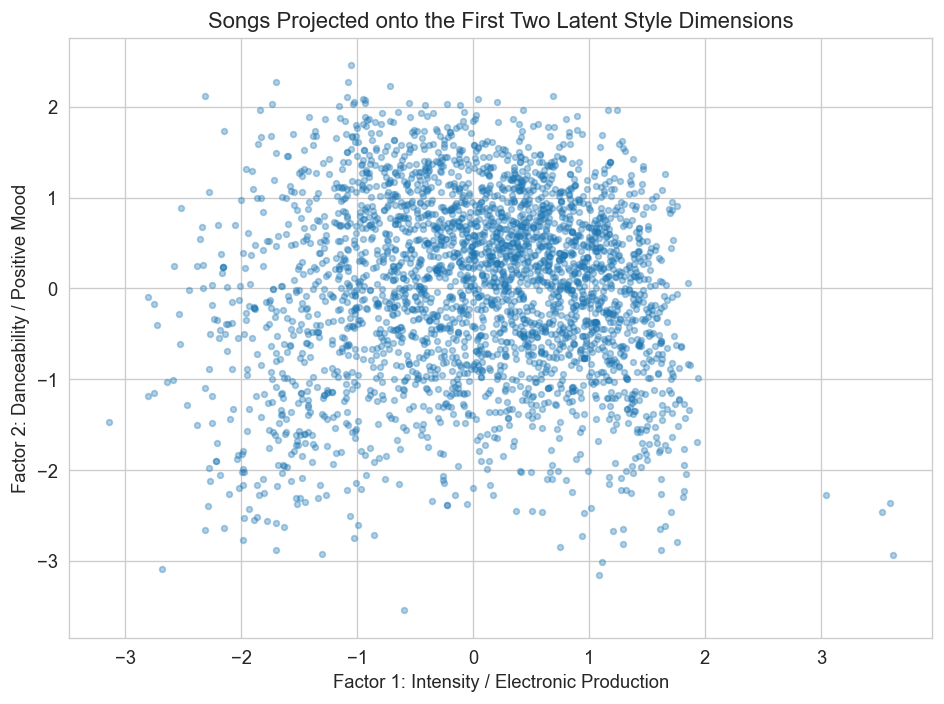

In [31]:
# 11. Factor Score Scatter Plot
# Purpose:
# This visualizes songs in the latent factor space.
# It also connects Q1 to Q2 clustering.
# ============================================================

plot_df = interpreted_scores.sample(
    n=min(3000, len(interpreted_scores)),
    random_state=42
)

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_df["Factor1_Intensity_Electronic"],
    plot_df["Factor2_Danceability_Positive"],
    alpha=0.35,
    s=12
)

plt.xlabel("Factor 1: Intensity / Electronic Production")
plt.ylabel("Factor 2: Danceability / Positive Mood")
plt.title("Songs Projected onto the First Two Latent Style Dimensions")
plt.tight_layout()

scatter_path = os.path.join(OUTPUT_DIR, "Q1_factor_score_scatter.png")
plt.savefig(scatter_path, dpi=300)
plt.show()

In [32]:
# 12. Save Q1 Outputs for Q2
# Purpose:
# Q2 clustering should use these factor scores instead of the
# original 9 audio features.
# ============================================================

df_q1 = df.copy()

# Add factor scores back to the full dataset.
# Rows removed because of missing values will receive NaN factor scores.
for col in interpreted_scores.columns:
    df_q1[col] = np.nan
    df_q1.loc[interpreted_scores.index, col] = interpreted_scores[col]

# Save tables
q1_scores_path = os.path.join(OUTPUT_DIR, "Spotify_Q1_factor_scores.csv")
pca_summary_path = os.path.join(OUTPUT_DIR, "Q1_pca_summary.csv")
loading_path = os.path.join(OUTPUT_DIR, "Q1_factor_analysis_varimax_loadings.csv")
variance_path = os.path.join(OUTPUT_DIR, "Q1_factor_variance_table.csv")
communality_path = os.path.join(OUTPUT_DIR, "Q1_communality_uniqueness_table.csv")
mapping_path = os.path.join(OUTPUT_DIR, "Q1_factor_mapping_table.csv")

df_q1.to_csv(q1_scores_path, index=False)
pca_summary.to_csv(pca_summary_path, index=False)
interpreted_loadings.to_csv(loading_path)
factor_variance_table.to_csv(variance_path)
communality_table.to_csv(communality_path)
factor_mapping_df.to_csv(mapping_path, index=False)

print("\nSaved Q1 output files:")
print(f"1. {q1_scores_path}")
print(f"2. {pca_summary_path}")
print(f"3. {loading_path}")
print(f"4. {variance_path}")
print(f"5. {communality_path}")
print(f"6. {mapping_path}")

print("\nSaved Q1 figures:")
print(f"1. {corr_path}")
print(f"2. {scree_path}")
print(f"3. {cumvar_path}")
print(f"4. {loading_heatmap_path}")
print(f"5. {scatter_path}")


Saved Q1 output files:
1. q1_outputs\Spotify_Q1_factor_scores.csv
2. q1_outputs\Q1_pca_summary.csv
3. q1_outputs\Q1_factor_analysis_varimax_loadings.csv
4. q1_outputs\Q1_factor_variance_table.csv
5. q1_outputs\Q1_communality_uniqueness_table.csv
6. q1_outputs\Q1_factor_mapping_table.csv

Saved Q1 figures:
1. q1_outputs\Q1_correlation_heatmap.png
2. q1_outputs\Q1_pca_scree_plot.png
3. q1_outputs\Q1_pca_cumulative_variance.png
4. q1_outputs\Q1_factor_analysis_loading_heatmap.png
5. q1_outputs\Q1_factor_score_scatter.png
